In [1]:
import sys
from pathlib import Path
import torch

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import pandas as pd
import torch

import Python.config as cfg
import Python.utils as ut
import Python.simfun as sim
import Python.model2 as md
import Python.metric as me
import Python.bnn_mcmc as mcmc
import Python.bnn_train as train

seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

X, y, feature_true, signal, sim_info = sim.simfun_nonlinear(
    n=160,
    p=1,
    n_active=1,
    interaction=False,
    seed=seed,
    device=device,
)

In [3]:
# -----------------------------
# 1. Split data and true signal
# -----------------------------

split_cfg = cfg.SplitConfig(
    train_frac=0.60,
    val_frac=0.20,
    test_frac=0.20,
    seed=seed,
)

indices = ut.make_split(X.shape[0], split_cfg)
splits = ut.split_data(X, y, indices, mode="tensor")
signal_splits = ut.split_data(X, signal, indices, mode="tensor")

X_train = splits["X_train"]
y_train = splits["y_train"]
X_test = splits["X_test"]
signal_test = signal_splits["y_test"]

x_val_grid = torch.linspace(
    -torch.pi,
    torch.pi,
    201,
    device=device,
    dtype=X_train.dtype,
)[:, None]
signal_val_grid = torch.cos(x_val_grid[:, 0])

x_grid = torch.linspace(
    -torch.pi,
    torch.pi,
    400,
    device=device,
    dtype=X_train.dtype,
)[:, None]
signal_grid = torch.cos(x_grid[:, 0])

In [4]:
# -----------------------------
# 2. Direct-unit configuration
# -----------------------------

direct_arch = dict(
    H=3,
    gate_roles=("input", "breakpoint", "output"),
    gate_power=2.0,
    gate_tau=1.0,
)

experiments = pd.DataFrame([
    {"experiment": "A",  "parameterization": "direct unit", "gate": "none", "gate_roles": (), "init_sd": 0.5},
    {"experiment": "B1", "parameterization": "direct unit", "gate": "input+breakpoint+output", "gate_roles": direct_arch["gate_roles"], "init_sd": 0.082},
    {"experiment": "B2", "parameterization": "direct unit", "gate": "input+breakpoint+output", "gate_roles": direct_arch["gate_roles"], "init_sd": 0.25},
    {"experiment": "B3", "parameterization": "direct unit", "gate": "input+breakpoint+output", "gate_roles": direct_arch["gate_roles"], "init_sd": 0.5},
    {"experiment": "B4", "parameterization": "direct unit", "gate": "input+breakpoint+output", "gate_roles": direct_arch["gate_roles"], "init_sd": 1.0},
    {"experiment": "C",  "parameterization": "residual edge-level", "gate": "all current gates", "gate_roles": None, "init_sd": 0.5},
])

experiments

,experiment,parameterization,gate,gate_roles,init_sd
0,A,direct unit,none,(),0.500
1,B1,direct unit,input+breakpoint+output,"(input, breakpoint, output)",0.082
2,B2,direct unit,input+breakpoint+output,"(input, breakpoint, output)",0.250
3,B3,direct unit,input+breakpoint+output,"(input, breakpoint, output)",0.500
4,B4,direct unit,input+breakpoint+output,"(input, breakpoint, output)",1.000
5,C,residual edge-level,all current gates,None,0.500


In [5]:
# -----------------------------
# 3. MCMC reference for B1--B4
# -----------------------------

mcmc_model = md.DirectUnitBNNVI(
    X=X_train,
    y=y_train,
    family=sim_info["family"],
    sigma2=sim_info["sigma2"],
    init_sd=0.5,
    K_flow=0,
    **direct_arch,
).to(device)

mcmc_ref = mcmc.run_bnn_mcmc(
    model=mcmc_model,
    N=10000,
    S_max=100,
    burnin=2000,
    thin=1,
    seed=seed,
    print_every=500,
)

mcmc_xi = torch.as_tensor(
    mcmc_ref["xi_draws"],
    device=device,
    dtype=X_train.dtype,
)

mcmc_iter=00001 loglik=-179.114
mcmc_iter=00500 loglik=-143.984
mcmc_iter=01000 loglik=-144.070
mcmc_iter=01500 loglik=-141.802
mcmc_iter=02000 loglik=-141.611
mcmc_iter=02500 loglik=-143.328
mcmc_iter=03000 loglik=-140.530
mcmc_iter=03500 loglik=-142.484
mcmc_iter=04000 loglik=-140.036
mcmc_iter=04500 loglik=-139.517
mcmc_iter=05000 loglik=-141.361
mcmc_iter=05500 loglik=-142.489
mcmc_iter=06000 loglik=-141.285
mcmc_iter=06500 loglik=-141.989
mcmc_iter=07000 loglik=-141.703
mcmc_iter=07500 loglik=-140.002
mcmc_iter=08000 loglik=-142.396
mcmc_iter=08500 loglik=-140.325
mcmc_iter=09000 loglik=-142.476
mcmc_iter=09500 loglik=-143.444
mcmc_iter=10000 loglik=-140.870


In [6]:
# -----------------------------
# 4. Train B3
# -----------------------------

out = train.train_direct_bnn(
    X_train=X_train,
    y_train=y_train,
    X_eval=x_val_grid,
    signal_eval=signal_val_grid,
    X_final=X_test,
    signal_final=signal_test,
    mcmc_decoder=mcmc_model.decoder,
    mcmc_xi=mcmc_xi,
    family=sim_info["family"],
    sigma2=sim_info["sigma2"],
    init_sd=0.5,
    K_flow=8,
    flow_hidden_units=64,
    flow_hidden_layers=2,
    scale_clip=1.5,
    epochs=6000,
    lr=3e-4,
    R_train=100,
    R_eval=1000,
    R_final=5000,
    eval_every=250,
    seed=seed,
    **direct_arch,
)

epoch=0001 elbo=-234.901 valR2=-0.0040 pathN=0.751 cancel=0.799
epoch=0250 elbo=-184.180 valR2=0.0631 pathN=0.895 cancel=1.000
epoch=0500 elbo=-161.262 valR2=0.8504 pathN=1.994 cancel=1.000
epoch=0750 elbo=-159.208 valR2=0.8351 pathN=1.797 cancel=1.000
epoch=1000 elbo=-158.058 valR2=0.8034 pathN=1.804 cancel=1.000
epoch=1250 elbo=-157.623 valR2=0.8736 pathN=1.816 cancel=1.000
epoch=1500 elbo=-157.054 valR2=0.8773 pathN=1.840 cancel=1.000
epoch=1750 elbo=-157.060 valR2=0.8725 pathN=1.854 cancel=1.000
epoch=2000 elbo=-156.939 valR2=0.8427 pathN=1.858 cancel=1.000
epoch=2250 elbo=-156.988 valR2=0.8326 pathN=1.940 cancel=1.000
epoch=2500 elbo=-156.898 valR2=0.8098 pathN=1.892 cancel=1.000
epoch=2750 elbo=-156.867 valR2=0.8143 pathN=1.847 cancel=1.000
epoch=3000 elbo=-156.870 valR2=0.9067 pathN=1.921 cancel=1.000
epoch=3250 elbo=-156.669 valR2=0.8616 pathN=1.860 cancel=1.000
epoch=3500 elbo=-156.749 valR2=0.8058 pathN=1.829 cancel=1.000
epoch=3750 elbo=-156.664 valR2=0.8710 pathN=1.787 canc

In [7]:
# -----------------------------
# 5. Selected checkpoint
# -----------------------------

history = out["history"]
best_id = history["val_signal_r2"].idxmax()

print(
    history.loc[
        best_id,
        [
            "epoch",
            "expected_log_likelihood",
            "kl_q_prior",
            "val_signal_r2",
            "val_draw_r2_median",
            "val_zero_function_prob",
            "val_constant_function_prob",
            "expected_path_count",
            "cancellation_ratio_median",
        ],
    ]
)

epoch                         3000.000000
expected_log_likelihood       -142.697708
kl_q_prior                      14.172524
val_signal_r2                    0.906668
val_draw_r2_median               0.841260
val_zero_function_prob           0.000000
val_constant_function_prob       0.000000
expected_path_count              1.921000
cancellation_ratio_median        1.000000
Name: 12, dtype: float64


In [8]:
from IPython.display import display

print("===== Overall metrics =====")
display(
    pd.DataFrame([out["final"]["summary"]])
    .T.rename(columns={0: "value"})
)

print("\n===== Role diagnostics =====")
display(out["final"]["role_metrics"])

print("\n===== Ordered unit paths =====")
display(out["final"]["unit_metrics"])

print("\n===== Unit contribution energy =====")
display(out["final"]["contribution_metrics"])

print("\n===== Spike and conditional slab =====")
me.print_spike_slab_summary(out["final"]["summary"])
display(out["final"]["spike_slab_metrics"])

===== Overall metrics =====


,value
best_epoch,3000.000000
best_val_signal_r2,0.906668
expected_log_likelihood,-142.783127
expected_log_prior,-35.876156
expected_log_q,-21.777859
...,...
mcmc_cancellation_ratio_q025,0.509176
mcmc_cancellation_ratio_q25,0.996348
mcmc_cancellation_ratio_q50,1.000000
mcmc_cancellation_ratio_q75,1.050088



===== Role diagnostics =====


,epoch,role,gate_learned,margin_mean,margin_sd,margin_q025,margin_q25,margin_q50,margin_q75,margin_q975,mean_pip,active_count_mean,active_count_median,active_count_p_zero,gate_mean,active_gate_mean,abs_theta_mean,abs_theta_median
0,3000,input,True,1.150883,1.220534,-1.361748,0.313365,1.291505,1.977558,3.377384,0.813533,2.4406,3.0,0.0000,0.499740,0.614283,0.617412,0.342714
1,3000,breakpoint,True,-0.256437,1.366177,-2.983042,-1.181454,-0.242205,0.665763,2.365506,0.430067,1.2902,1.0,0.3148,0.176206,0.409717,0.121515,0.000000
2,3000,output,True,0.965731,1.240069,-1.526406,0.066776,1.093662,1.834412,3.233465,0.765733,2.2972,2.0,0.0000,0.448890,0.586223,0.552928,0.233512



===== Ordered unit paths =====


,epoch,unit_rank,input_pip,breakpoint_pip,output_pip,path_probability,input_output_joint,input_output_product,joint_minus_product,joint_over_product,breakpoint_defined_prob
0,3000,1,1.0000,0.5020,0.7718,0.7718,0.7718,0.771800,0.000000,1.000000,1.0000
1,3000,2,0.8776,0.3432,0.7822,0.6920,0.6920,0.686459,0.005541,1.008072,0.8756
2,3000,3,0.5630,0.4450,0.7432,0.4384,0.4384,0.418422,0.019978,1.047747,0.5510



===== Unit contribution energy =====


,epoch,unit_rank,energy_mean,energy_median,energy_q025,energy_q25,energy_q50,energy_q75,energy_q975,energy_active_prob
0,3000,1,1.681513,0.001658,0.0,0.0,0.001662,3.913943,6.691065,0.6850
1,3000,2,1.881294,0.001733,0.0,0.0,0.001758,4.291985,7.112797,0.6598
2,3000,3,1.375473,0.000000,0.0,0.0,0.000000,3.130147,6.974821,0.4342



===== Spike and conditional slab =====
reference-active JS: 0.005844
reference-inactive JS: 0.002874


,role,unit_rank,rat_pip,mcmc_pip,zero_mass_js,reference_group,rat_active_draws,mcmc_active_draws,conditional_slab_skl,rat_active_gate_mean,mcmc_active_gate_mean,rat_active_slab_abs_mean,mcmc_active_slab_abs_mean
0,input,1,1.0000,1.000000,0.000000,reference-active,5000,8000,0.157301,0.584521,0.649537,1.075855,1.309953
1,input,2,0.8776,0.927250,0.003534,reference-active,4388,7418,0.168292,0.625482,0.643760,1.181954,1.224995
2,input,3,0.5630,0.680000,0.007296,reference-active,2815,5440,0.292373,0.649691,0.617026,1.206622,0.967671
3,breakpoint,1,0.5020,0.619875,0.007070,reference-active,2510,4959,0.067379,0.418924,0.482253,0.716097,0.840113
4,breakpoint,2,0.3432,0.416750,0.002874,reference-inactive,1716,3334,0.030803,0.395645,0.440767,0.636518,0.680989
5,breakpoint,3,0.4450,0.521375,0.002923,reference-active,2225,4171,0.024441,0.410184,0.441744,0.734290,0.770768
6,output,1,0.7718,0.895750,0.014143,reference-active,3859,7166,0.162178,0.590879,0.680943,1.137575,1.388798
7,output,2,0.7822,0.870875,0.006920,reference-active,3911,6967,0.060054,0.600533,0.651681,1.177677,1.253796
8,output,3,0.7432,0.824250,0.004867,reference-active,3716,6594,0.090941,0.566327,0.598124,1.062585,0.949376


In [9]:
# Every checkpoint is retained in these four tables.

display(out["history"])
display(out["role_history"])
display(out["unit_history"])
display(out["contribution_history"])

,epoch,loss,expected_log_likelihood,expected_log_prior,expected_log_q,kl_q_prior,elbo,expected_path_count,beta0_abs_mean,beta0_abs_median,...,unit_energy_sum_median,total_unit_energy_mean,total_unit_energy_median,cancellation_ratio_mean,cancellation_ratio_median,cancellation_ratio_q025,cancellation_ratio_q25,cancellation_ratio_q50,cancellation_ratio_q75,cancellation_ratio_q975
0,1,227.337173,-227.719666,-24.056431,-16.875305,7.181128,-234.900803,0.751,0.412370,0.351569,...,1.673525e-09,0.001156,1.717640e-09,0.548540,0.798882,0.000000,0.00000,0.799046,1.000000,1.527645
1,250,183.655716,-178.981995,-30.392473,-25.194975,5.197495,-184.179504,0.895,0.131714,0.115305,...,4.910439e-06,0.067858,4.874541e-06,0.620942,0.999989,0.000000,0.00000,0.999990,1.000000,1.710780
2,500,160.806198,-144.186188,-34.073574,-16.997986,17.075586,-161.261765,1.994,1.326140,1.314896,...,5.262658e+00,5.330688,5.295770e+00,1.008625,1.000000,0.888743,0.99999,1.000000,1.001146,1.199156
3,750,159.423492,-143.671341,-34.620716,-19.083721,15.536995,-159.208328,1.797,1.322084,1.321893,...,5.106181e+00,5.227539,5.099905e+00,1.004425,1.000000,0.911664,1.00000,1.000000,1.000000,1.159610
4,1000,158.050552,-142.934280,-35.416328,-20.292879,15.123447,-158.057739,1.804,1.355168,1.353386,...,5.425234e+00,5.551466,5.445956e+00,1.007976,1.000000,0.918003,1.00000,1.000000,1.000045,1.147592
5,1250,158.623016,-142.805023,-35.165012,-20.347281,14.817726,-157.622757,1.816,1.379009,1.383584,...,5.066608e+00,5.192677,5.076862e+00,1.004495,1.000000,0.909962,1.00000,1.000000,1.000000,1.141615
6,1500,157.034454,-142.692398,-35.390194,-21.028507,14.361689,-157.054077,1.840,1.335073,1.334946,...,5.057026e+00,5.131153,5.055826e+00,1.001191,1.000000,0.852623,1.00000,1.000000,1.000000,1.164234
7,1750,157.010056,-142.594803,-35.347855,-20.882416,14.465442,-157.060242,1.854,1.370065,1.373817,...,4.992701e+00,5.098246,4.994886e+00,1.002839,1.000000,0.892413,1.00000,1.000000,1.000034,1.124030
8,2000,157.244202,-142.588989,-35.402012,-21.051792,14.350222,-156.939209,1.858,1.355331,1.363044,...,5.260945e+00,5.304149,5.269732e+00,1.004889,1.000000,0.889888,1.00000,1.000000,1.000056,1.147802
9,2250,156.621307,-142.693604,-35.526661,-21.232269,14.294393,-156.988022,1.940,1.356738,1.351736,...,5.086967e+00,5.302505,5.101259e+00,1.010242,1.000000,0.886238,1.00000,1.000000,1.000533,1.237855


,epoch,role,gate_learned,margin_mean,margin_sd,margin_q025,margin_q25,margin_q50,margin_q75,margin_q975,...,gate_mean,active_gate_mean,abs_theta_mean,abs_theta_median,grad_s_norm,grad_u_norm,grad_t_norm,q0_loc_grad_s_norm,q0_loc_grad_u_norm,q0_loc_grad_t_norm
0,1,input,True,0.019485,0.704114,-1.365254,-0.455063,0.005210,0.489564,1.427119,...,0.125052,0.248776,0.051037,0.000002,1.612047,1.419611,1.153805,0.355478,0.304704,0.300816
1,1,breakpoint,True,-0.011028,0.702768,-1.363517,-0.467541,-0.008889,0.460689,1.359267,...,0.116830,0.236021,0.044744,0.000000,1.053893,1.034026,0.697914,0.044005,0.052188,0.032848
2,1,output,True,-0.003500,0.709006,-1.343323,-0.489909,0.011575,0.478357,1.392053,...,0.120990,0.238483,0.045828,0.000019,1.654629,2.118348,1.770414,0.320322,0.204632,0.211334
3,250,input,True,0.280324,1.395412,-2.478908,-0.675390,0.285747,1.214652,3.013242,...,0.282643,0.490415,0.188486,0.022471,4.246768,2.724918,1.988988,0.469907,0.402946,0.683712
4,250,breakpoint,True,-0.253055,1.252200,-2.756487,-1.092398,-0.230134,0.581091,2.190244,...,0.160340,0.376385,0.109520,0.000000,2.081798,1.661111,0.867399,0.596581,0.585970,0.032046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,5750,breakpoint,True,-0.027291,1.397084,-2.718578,-1.006020,-0.019372,0.909642,2.695179,...,0.220070,0.445487,0.162867,0.000000,3.424250,2.200977,1.664362,0.325523,0.195868,0.264075
71,5750,output,True,0.875212,1.260175,-1.668223,-0.046617,1.018388,1.753114,3.190564,...,0.427042,0.578125,0.553603,0.215620,10.965896,9.246293,8.725441,0.957035,1.443752,0.896091
72,6000,input,True,1.079138,1.247314,-1.534670,0.229066,1.234502,1.925164,3.357151,...,0.481856,0.606872,0.608153,0.294677,12.860518,7.835566,7.000915,0.628103,0.559472,0.418220
73,6000,breakpoint,True,-0.059680,1.346618,-2.796492,-0.943505,-0.025552,0.857418,2.495417,...,0.209098,0.423560,0.144830,0.000000,2.638056,2.325048,1.548718,0.186130,0.332748,0.205785


,epoch,unit_rank,input_pip,breakpoint_pip,output_pip,path_probability,input_output_joint,input_output_product,joint_minus_product,joint_over_product,breakpoint_defined_prob
0,1,1,0.758,0.512,0.506,0.380,0.380,0.383548,-0.003548,0.990750,0.754
1,1,2,0.490,0.461,0.510,0.239,0.239,0.249900,-0.010900,0.956383,0.479
2,1,3,0.260,0.512,0.506,0.132,0.132,0.131560,0.000440,1.003345,0.240
3,250,1,0.814,0.467,0.523,0.422,0.422,0.425722,-0.003722,0.991257,0.813
4,250,2,0.599,0.377,0.529,0.319,0.319,0.316871,0.002129,1.006719,0.596
...,...,...,...,...,...,...,...,...,...,...,...
70,5750,2,0.855,0.414,0.748,0.655,0.655,0.639540,0.015460,1.024174,0.853
71,5750,3,0.560,0.497,0.717,0.435,0.435,0.401520,0.033480,1.083383,0.551
72,6000,1,1.000,0.583,0.783,0.783,0.783,0.783000,0.000000,1.000000,1.000
73,6000,2,0.856,0.416,0.760,0.658,0.658,0.650560,0.007440,1.011436,0.852


,epoch,unit_rank,energy_mean,energy_median,energy_q025,energy_q25,energy_q50,energy_q75,energy_q975,energy_active_prob
0,1,1,0.000616,0.000000,0.0,0.0,0.000000,2.800385e-07,0.002147,0.212
1,1,2,0.000371,0.000000,0.0,0.0,0.000000,8.971059e-10,0.001143,0.173
2,1,3,0.000153,0.000000,0.0,0.0,0.000000,0.000000e+00,0.000890,0.112
3,250,1,0.028364,0.000000,0.0,0.0,0.000000,2.004625e-04,0.232866,0.344
4,250,2,0.013897,0.000000,0.0,0.0,0.000000,1.747000e-05,0.155873,0.292
...,...,...,...,...,...,...,...,...,...,...
70,5750,2,1.961601,0.000840,0.0,0.0,0.000864,4.607577e+00,7.613420,0.627
71,5750,3,1.396194,0.000000,0.0,0.0,0.000000,1.337287e-01,7.451854,0.429
72,6000,1,1.918306,0.003417,0.0,0.0,0.003482,4.176600e+00,6.818744,0.687
73,6000,2,1.747281,0.000469,0.0,0.0,0.000477,4.025867e+00,6.643447,0.616


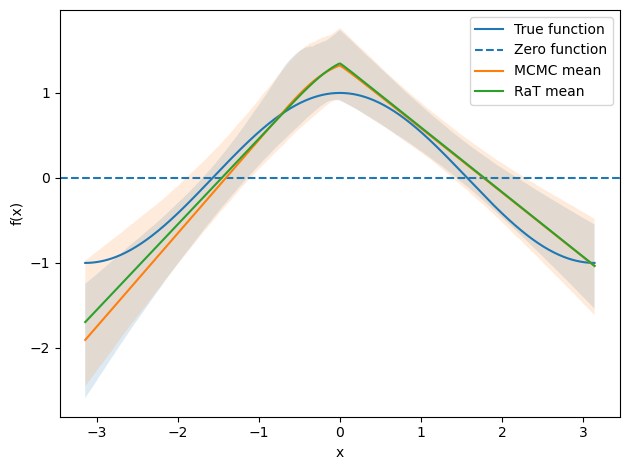

In [10]:
# -----------------------------
# 6. Function posterior plot
# -----------------------------

mcmc_grid = me.predict_draws(
    mcmc_model.decoder,
    x_grid,
    mcmc_xi,
)

rat_grid = me.predict_draws(
    out["model"].decoder,
    x_grid,
    out["final"]["xi"],
)

fig, ax = me.plot_function_1d(
    x=x_grid[:, 0].cpu(),
    signal=signal_grid.cpu(),
    mcmc_pred_draws=mcmc_grid,
    rat_pred_draws=rat_grid,
)

For experiment A, set `gate_roles=()` in both `mcmc_model` and `train_direct_bnn`. For the role-isolation runs, fix one gate open by omitting that role: input fixed uses `("breakpoint", "output")`; output fixed uses `("input", "breakpoint")`; breakpoint fixed uses `("input", "output")`. B1--B4 share the same all-gated MCMC reference because `init_sd` changes only the variational initialization.